<a href="https://colab.research.google.com/github/2403a52267/AIAC/blob/main/ML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Career path Recommendation with machine learning Techniques

step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

step2: upload Dataset

In [ ]:
df = pd.read_csv("/content/career_recommender.csv")
print(df.info)

<bound method DataFrame.info of      What is your name? What is your gender? What was your course in UG?  \
0           A.Uha Priya               Female                        B.Sc   
1                 Aadil                 Male                         B.E   
2               Aakriti               Female                          BA   
3        Aanchal sharma               Female                         MBA   
4      Aangkeeta Sarkar               Female                      B.Tech   
...                 ...                  ...                         ...   
1190       Your Friend                  Male                      B.Tech   
1191        Zabi ansari                 Male                        B.Sc   
1192               Zain                 Male                      B.Tech   
1193          Zayn Shah                 Male                          BE   
1194    Zuben Saldanha                  Male                        B.Sc   

     What is your UG specialization? Major Subject (Eg;

In [ ]:
print(df.head())

  What is your name? What is your gender? What was your course in UG?  \
0        A.Uha Priya               Female                        B.Sc   
1              Aadil                 Male                         B.E   
2            Aakriti               Female                          BA   
3     Aanchal sharma               Female                         MBA   
4   Aangkeeta Sarkar               Female                      B.Tech   

  What is your UG specialization? Major Subject (Eg; Mathematics)  \
0                              Computer Applications                
1                       Computer Science Engineering                
2                                         Psychology                
3                                           Commerce                
4                        Instrumentation Engineering                

                            What are your interests?  \
0                                    Cloud computing   
1                                 

step 3:Data Preprocessing

In [ ]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nEncoded Dataset:")
display(df.head())

# Feature Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)


Missing Values:
What is your name?                                                                                                          0
What is your gender?                                                                                                        0
What was your course in UG?                                                                                                 0
What is your UG specialization? Major Subject (Eg; Mathematics)                                                             0
What are your interests?                                                                                                    0
What are your skills ? (Select multiple if necessary)                                                                       0
What was the average CGPA or Percentage obtained in under graduation?                                                       0
Did you do any certification courses additionally?                                                   

/tmp/ipykernel_3390/2355019501.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,What is your name?,What is your gender?,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,Did you do any certification courses additionally?,"If yes, please specify your certificate course title.",Are you working?,"If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.","Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)"
0,0,0,13,80,7,943,265,2,314,1,381,64
1,10,1,6,87,476,541,96,2,338,1,96,64
2,11,0,15,253,580,766,81,2,428,0,96,64
3,12,0,50,73,401,134,189,1,355,1,338,64
4,13,0,14,184,476,11,135,2,244,1,289,64


STEP 4: Data Visualization

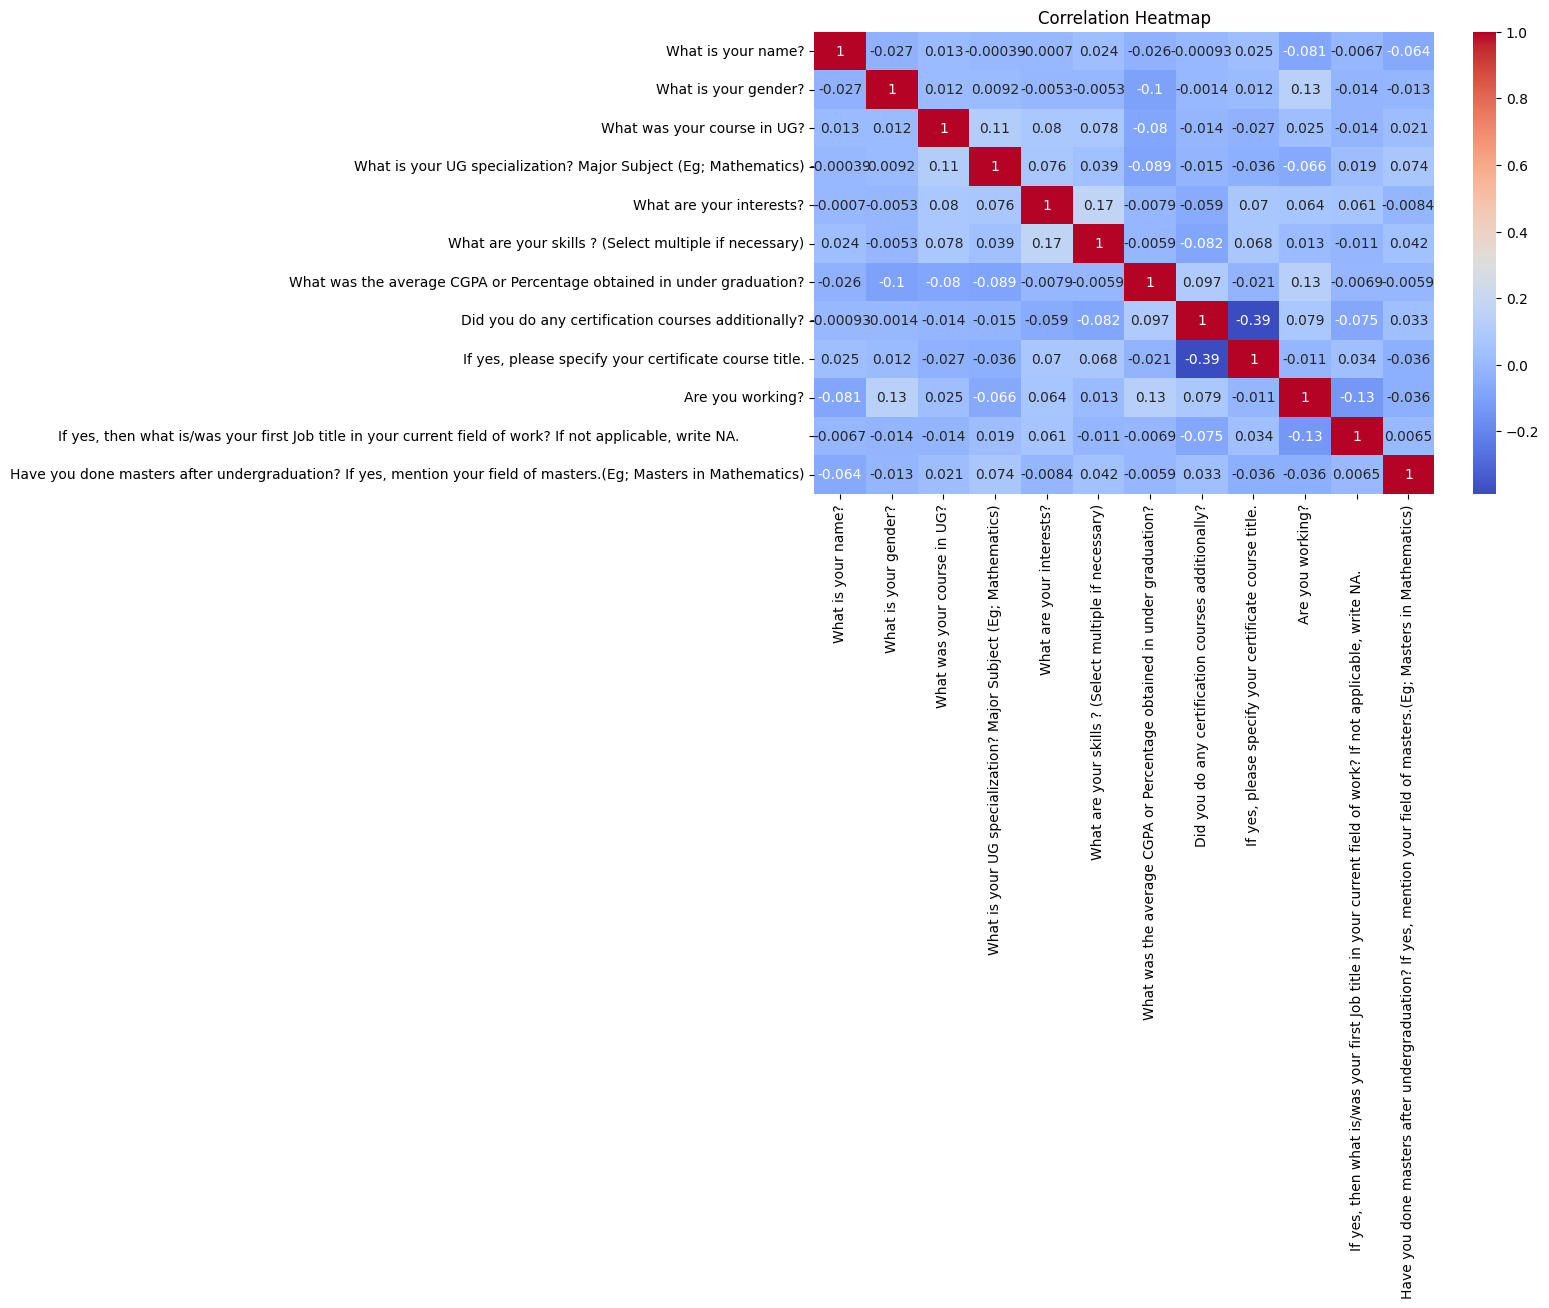

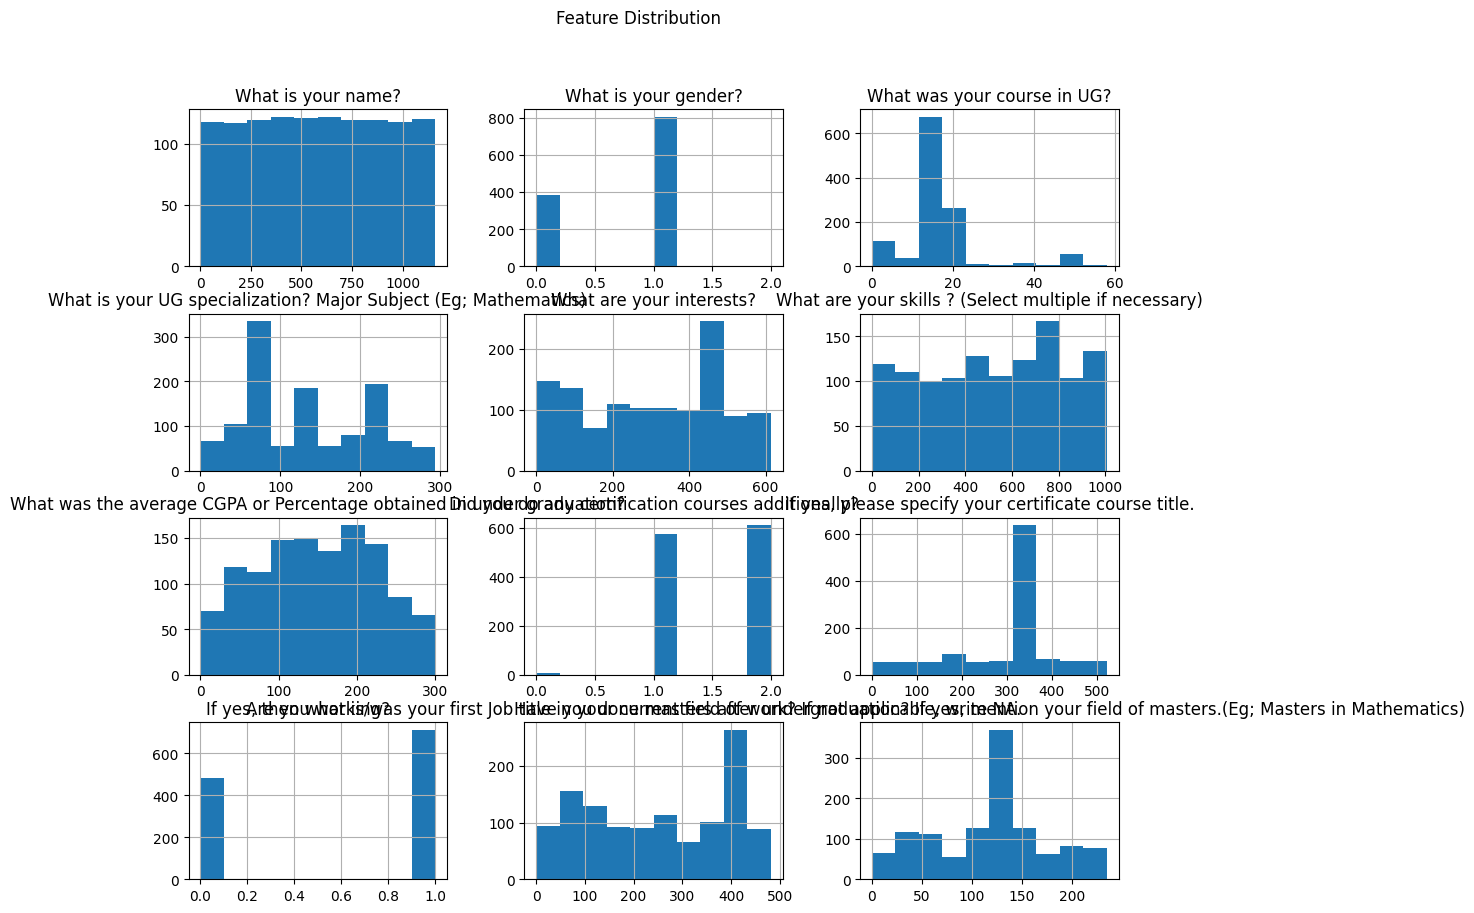

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-define df and apply necessary preprocessing as it appears undefined
df = pd.read_csv("/content/career_recommender.csv")

# Fill missing values (copied from cell YYr6nveMqMKW)
df.ffill(inplace=True)

# Encode categorical columns (copied from cell YYr6nveMqMKW)
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribution Plot
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

Step5: Feature Selection & Train-Test Split

In [ ]:
X = df.drop(columns=[target_column])
y = df[target_column]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (956, 11)
Testing Size: (239, 11)


Step6: Machine Learning Models

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Logistic Regression (main model for classification)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Step7:Model Evaluation

In [ ]:
# Predictions
y_pred = log_reg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.058577405857740586

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         1
          19       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          29       1.00      1.00      1.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Step8:ROC Curve

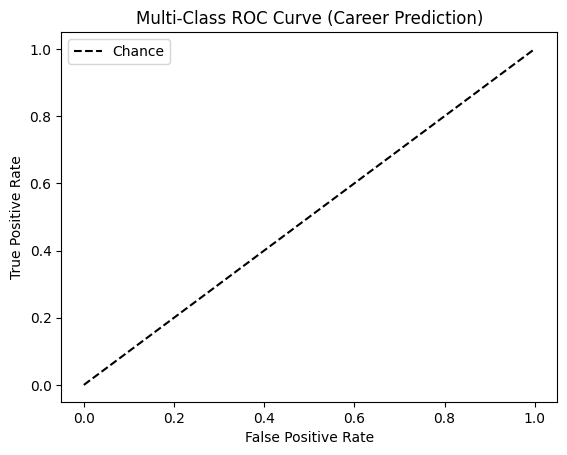

In [5]:
import matplotlib.pyplot as plt

# Diagonal line
plt.plot([0,1], [0,1], 'k--', label='Chance')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Career Prediction)")
plt.legend()
plt.show()

Step 9:Sample Predictions

In [ ]:
sample = X_test.iloc[0:5]
predictions = log_reg.predict(sample)

print("\nSample Predictions:")
for i, pred in enumerate(predictions):
    print(f"Student {i+1} → Recommended Career: {pred}")


Sample Predictions:
Student 1 → Recommended Career: 127
Student 2 → Recommended Career: 173
Student 3 → Recommended Career: 37
Student 4 → Recommended Career: 167
Student 5 → Recommended Career: 216


Step 10: Prediction Visualization

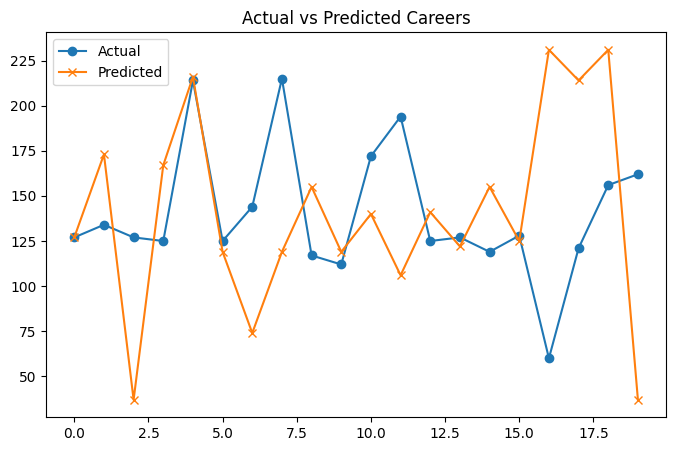

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:20], label="Actual", marker='o')
plt.plot(y_pred[:20], label="Predicted", marker='x')
plt.title("Actual vs Predicted Careers")
plt.legend()
plt.show()

Step 11: Final Career Recommendation Example

In [ ]:
# Example new student data (modify based on your dataset columns)
new_student = np.array([X.iloc[0]])  # using sample

prediction = log_reg.predict(new_student)

print("\nFinal Career Recommendation:")
print("Recommended Career Path:", prediction[0])


Final Career Recommendation:
Recommended Career Path: 40


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
